# 📊 Data Exploration & Overview

**UIDAI Aadhaar Insights Project**

This notebook provides an introduction to the UIDAI Aadhaar datasets with interactive exploration.

---

## 📌 Objectives
1. Load and understand the three core datasets
2. Assess data quality (missing values, duplicates)
3. Generate summary statistics
4. Create initial visualizations

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Define paths
DATA_DIR = Path('../data/processed')

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


---

## 1️⃣ Load Datasets

We have three main datasets:
- **Enrolment**: New Aadhaar registrations
- **Demographic Updates**: Changes to demographic information
- **Biometric Updates**: Updates to biometric data

In [2]:
# Load all three datasets
print('Loading datasets...')

enrolment = pd.read_csv(DATA_DIR / 'cleaned_enrolment.csv', parse_dates=['date'])
demographic = pd.read_csv(DATA_DIR / 'cleaned_demographic.csv', parse_dates=['date'])
biometric = pd.read_csv(DATA_DIR / 'cleaned_biometric.csv', parse_dates=['date'])

datasets = {
    'Enrolment': enrolment,
    'Demographic': demographic,
    'Biometric': biometric
}

print('✅ All datasets loaded!')

Loading datasets...
✅ All datasets loaded!


---

## 2️⃣ Dataset Overview

Let's understand the structure and size of each dataset.

In [3]:
# Dataset shapes
print('=' * 60)
print('📊 DATASET DIMENSIONS')
print('=' * 60)

for name, df in datasets.items():
    print(f'\n{name}:')
    print(f'  📦 Rows: {df.shape[0]:,}')
    print(f'  📋 Columns: {df.shape[1]}')
    print(f'  💾 Memory: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')

📊 DATASET DIMENSIONS

Enrolment:
  📦 Rows: 981,295
  📋 Columns: 11
  💾 Memory: 200.73 MB

Demographic:
  📦 Rows: 1,225,607
  📋 Columns: 10
  💾 Memory: 241.14 MB

Biometric:
  📦 Rows: 1,476,599
  📋 Columns: 10
  💾 Memory: 290.38 MB


In [4]:
# Column information
print('=' * 60)
print('📋 COLUMN DETAILS')
print('=' * 60)

for name, df in datasets.items():
    print(f'\n🔹 {name} Dataset:')
    print(f'   Columns: {list(df.columns)}')

📋 COLUMN DETAILS

🔹 Enrolment Dataset:
   Columns: ['date', 'state', 'district', 'pincode', 'age_0_5', 'age_5_17', 'age_18_greater', 'year', 'month', 'quarter', 'day_of_week']

🔹 Demographic Dataset:
   Columns: ['date', 'state', 'district', 'pincode', 'demo_age_5_17', 'demo_age_17_', 'year', 'month', 'quarter', 'day_of_week']

🔹 Biometric Dataset:
   Columns: ['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_', 'year', 'month', 'quarter', 'day_of_week']


In [5]:
# Sample data from each dataset
print('=' * 60)
print('👀 SAMPLE DATA - ENROLMENT')
print('=' * 60)
enrolment.head()

👀 SAMPLE DATA - ENROLMENT


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,year,month,quarter,day_of_week
0,2025-10-26,Andhra Pradesh,Nalgonda,508004,0,1,0,2025,10,4,6
1,2025-10-26,Andhra Pradesh,Nalgonda,508238,1,0,0,2025,10,4,6
2,2025-10-26,Andhra Pradesh,Nalgonda,508278,1,0,0,2025,10,4,6
3,2025-10-26,Andhra Pradesh,Nandyal,518432,0,1,0,2025,10,4,6
4,2025-10-26,Andhra Pradesh,Nandyal,518543,1,0,0,2025,10,4,6


In [6]:
print('=' * 60)
print('👀 SAMPLE DATA - DEMOGRAPHIC')
print('=' * 60)
demographic.head()

👀 SAMPLE DATA - DEMOGRAPHIC


,date,state,district,pincode,demo_age_5_17,demo_age_17_,year,month,quarter,day_of_week
0,2025-01-11,Puducherry,Karaikal,609603,0,4,2025.00,1.00,1.00,5.00
1,2025-01-11,Puducherry,Karaikal,609605,0,3,2025.00,1.00,1.00,5.00
2,2025-01-11,Puducherry,Karaikal,609606,0,5,2025.00,1.00,1.00,5.00
3,2025-01-11,Puducherry,Puducherry,605011,2,6,2025.00,1.00,1.00,5.00
4,2025-01-11,Puducherry,Puducherry,605111,0,1,2025.00,1.00,1.00,5.00


In [7]:
print('=' * 60)
print('👀 SAMPLE DATA - BIOMETRIC')
print('=' * 60)
biometric.head()

👀 SAMPLE DATA - BIOMETRIC


,date,state,district,pincode,bio_age_5_17,bio_age_17_,year,month,quarter,day_of_week
0,2025-08-12,Uttar Pradesh,Moradabad,244411,4,2,2025.00,8.00,3.00,1.00
1,2025-08-12,Uttar Pradesh,Moradabad,244601,14,19,2025.00,8.00,3.00,1.00
2,2025-08-12,Uttar Pradesh,Muzaffarnagar,251002,22,37,2025.00,8.00,3.00,1.00
3,2025-08-12,Uttar Pradesh,Muzaffarnagar,251202,4,4,2025.00,8.00,3.00,1.00
4,2025-08-12,Uttar Pradesh,Muzaffarnagar,251319,4,7,2025.00,8.00,3.00,1.00


---

## 3️⃣ Data Quality Assessment

Check for missing values, duplicates, and data types.

In [8]:
# Missing values analysis
print('=' * 60)
print('🔍 MISSING VALUES ANALYSIS')
print('=' * 60)

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    
    print(f'\n🔹 {name}:')
    if missing.sum() == 0:
        print('   ✅ No missing values!')
    else:
        print(missing[missing > 0])

🔍 MISSING VALUES ANALYSIS

🔹 Enrolment:
   ✅ No missing values!

🔹 Demographic:
date           567803
year           567803
month          567803
quarter        567803
day_of_week    567803
dtype: int64

🔹 Biometric:
date           655579
year           655579
month          655579
quarter        655579
day_of_week    655579
dtype: int64


In [9]:
# Data types
print('=' * 60)
print('📊 DATA TYPES')
print('=' * 60)

for name, df in datasets.items():
    print(f'\n🔹 {name}:')
    print(df.dtypes.to_string())

📊 DATA TYPES

🔹 Enrolment:
date              datetime64[ns]
state                     object
district                  object
pincode                    int64
age_0_5                    int64
age_5_17                   int64
age_18_greater             int64
year                       int64
month                      int64
quarter                    int64
day_of_week                int64

🔹 Demographic:
date             datetime64[ns]
state                    object
district                 object
pincode                   int64
demo_age_5_17             int64
demo_age_17_              int64
year                    float64
month                   float64
quarter                 float64
day_of_week             float64

🔹 Biometric:
date            datetime64[ns]
state                   object
district                object
pincode                  int64
bio_age_5_17             int64
bio_age_17_              int64
year                   float64
month                  float64
quarter     

In [10]:
# Date range for each dataset
print('=' * 60)
print('📅 DATE RANGES')
print('=' * 60)

for name, df in datasets.items():
    print(f'\n🔹 {name}:')
    print(f'   Start: {df["date"].min()}')
    print(f'   End: {df["date"].max()}')
    print(f'   Days: {(df["date"].max() - df["date"].min()).days}')

📅 DATE RANGES

🔹 Enrolment:
   Start: 2025-03-02 00:00:00
   End: 2025-12-31 00:00:00
   Days: 304

🔹 Demographic:
   Start: 2025-01-03 00:00:00
   End: 2025-12-12 00:00:00
   Days: 343

🔹 Biometric:
   Start: 2025-01-03 00:00:00
   End: 2025-12-12 00:00:00
   Days: 343


---

## 4️⃣ Summary Statistics

Generate descriptive statistics for numeric columns.

In [11]:
# Enrolment statistics
print('📊 ENROLMENT SUMMARY STATISTICS')
enrolment.describe()

📊 ENROLMENT SUMMARY STATISTICS


,date,pincode,age_0_5,age_5_17,age_18_greater,year,month,quarter,day_of_week
count,981295,981295.00,981295.00,981295.00,981295.00,981295.00,981295.00,981295.00,981295.00
mean,2025-10-23 12:01:43.675245824,518515.47,2.97,1.26,0.11,2025.00,10.22,3.63,2.70
min,2025-03-02 00:00:00,100000.00,0.00,0.00,0.00,2025.00,3.00,1.00,0.00
25%,2025-09-18 00:00:00,363641.00,1.00,0.00,0.00,2025.00,9.00,3.00,1.00
50%,2025-10-26 00:00:00,517417.00,2.00,0.00,0.00,2025.00,10.00,4.00,3.00
75%,2025-11-15 00:00:00,700088.00,3.00,1.00,0.00,2025.00,11.00,4.00,4.00
max,2025-12-31 00:00:00,855456.00,150.00,149.00,150.00,2025.00,12.00,4.00,6.00
std,NaN,205414.27,5.18,3.49,1.42,0.00,1.12,0.48,1.99


In [12]:
# Demographic statistics
print('📊 DEMOGRAPHIC SUMMARY STATISTICS')
demographic.describe()

📊 DEMOGRAPHIC SUMMARY STATISTICS


,date,pincode,demo_age_5_17,demo_age_17_,year,month,quarter,day_of_week
count,657804,1225607.00,1225607.00,1225607.00,657804.00,657804.00,657804.00,657804.00
mean,2025-06-27 02:06:36.271229952,524452.71,1.75,14.99,2025.00,6.53,2.51,3.16
min,2025-01-03 00:00:00,100000.00,0.00,0.00,2025.00,1.00,1.00,0.00
25%,2025-03-12 00:00:00,391421.00,0.00,3.00,2025.00,3.00,1.00,1.00
50%,2025-07-09 00:00:00,522257.00,1.00,7.00,2025.00,7.00,3.00,3.00
75%,2025-10-09 00:00:00,695527.00,2.00,18.00,2025.00,10.00,4.00,5.00
max,2025-12-12 00:00:00,855456.00,145.00,150.00,2025.00,12.00,4.00,6.00
std,NaN,199478.54,2.90,20.55,0.00,3.50,1.13,1.93


In [13]:
# Biometric statistics
print('📊 BIOMETRIC SUMMARY STATISTICS')
biometric.describe()

📊 BIOMETRIC SUMMARY STATISTICS


,date,pincode,bio_age_5_17,bio_age_17_,year,month,quarter,day_of_week
count,821020,1476599.00,1476599.00,1476599.00,821020.00,821020.00,821020.00,821020.00
mean,2025-06-14 23:02:47.972522240,519100.67,10.46,10.39,2025.00,6.14,2.39,3.16
min,2025-01-03 00:00:00,110001.00,0.00,0.00,2025.00,1.00,1.00,0.00
25%,2025-03-09 00:00:00,388345.00,1.00,2.00,2025.00,3.00,1.00,1.00
50%,2025-06-11 00:00:00,521110.00,4.00,4.00,2025.00,6.00,2.00,3.00
75%,2025-09-12 00:00:00,686102.00,11.00,11.00,2025.00,9.00,3.00,5.00
max,2025-12-12 00:00:00,855456.00,150.00,150.00,2025.00,12.00,4.00,6.00
std,NaN,199098.63,17.61,17.80,0.00,3.69,1.17,1.99


---

## 5️⃣ Initial Visualizations

Quick visual overview of the data.

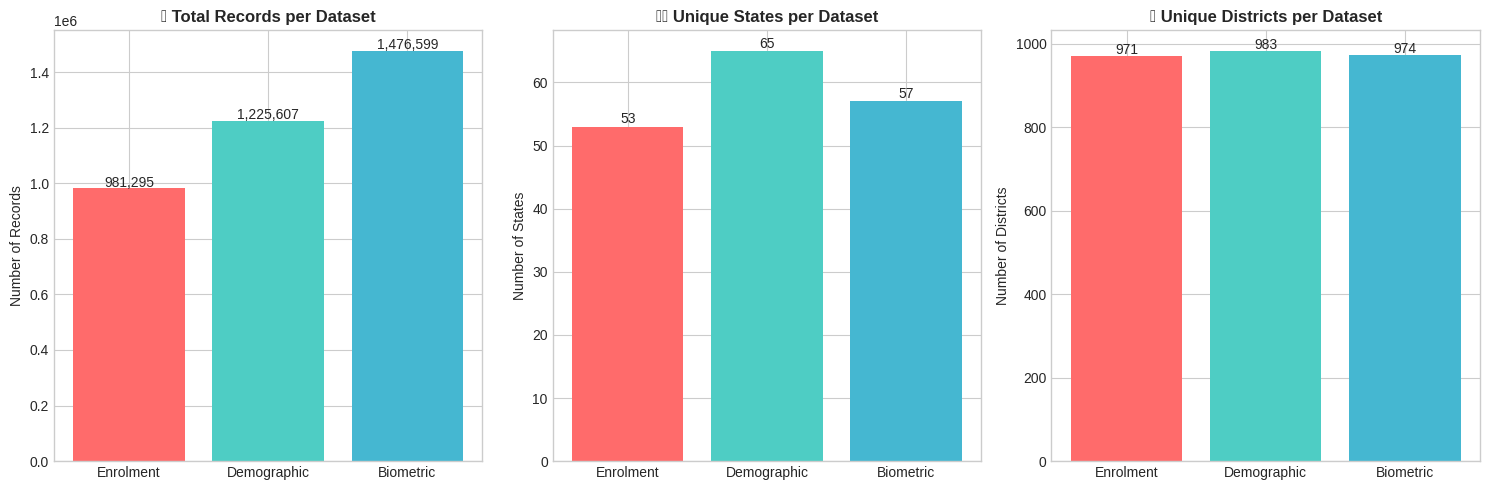

In [14]:
# Create figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Total records per dataset
dataset_totals = [len(df) for df in datasets.values()]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

axes[0].bar(datasets.keys(), dataset_totals, color=colors)
axes[0].set_title('📊 Total Records per Dataset', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Records')
for i, v in enumerate(dataset_totals):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontsize=10)

# Unique states
unique_states = [df['state'].nunique() for df in datasets.values()]
axes[1].bar(datasets.keys(), unique_states, color=colors)
axes[1].set_title('🗺️ Unique States per Dataset', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of States')
for i, v in enumerate(unique_states):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontsize=10)

# Unique districts
unique_districts = [df['district'].nunique() for df in datasets.values()]
axes[2].bar(datasets.keys(), unique_districts, color=colors)
axes[2].set_title('📍 Unique Districts per Dataset', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Number of Districts')
for i, v in enumerate(unique_districts):
    axes[2].text(i, v + 5, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

TypeError: unsupported operand type(s) for +: 'float' and 'str'

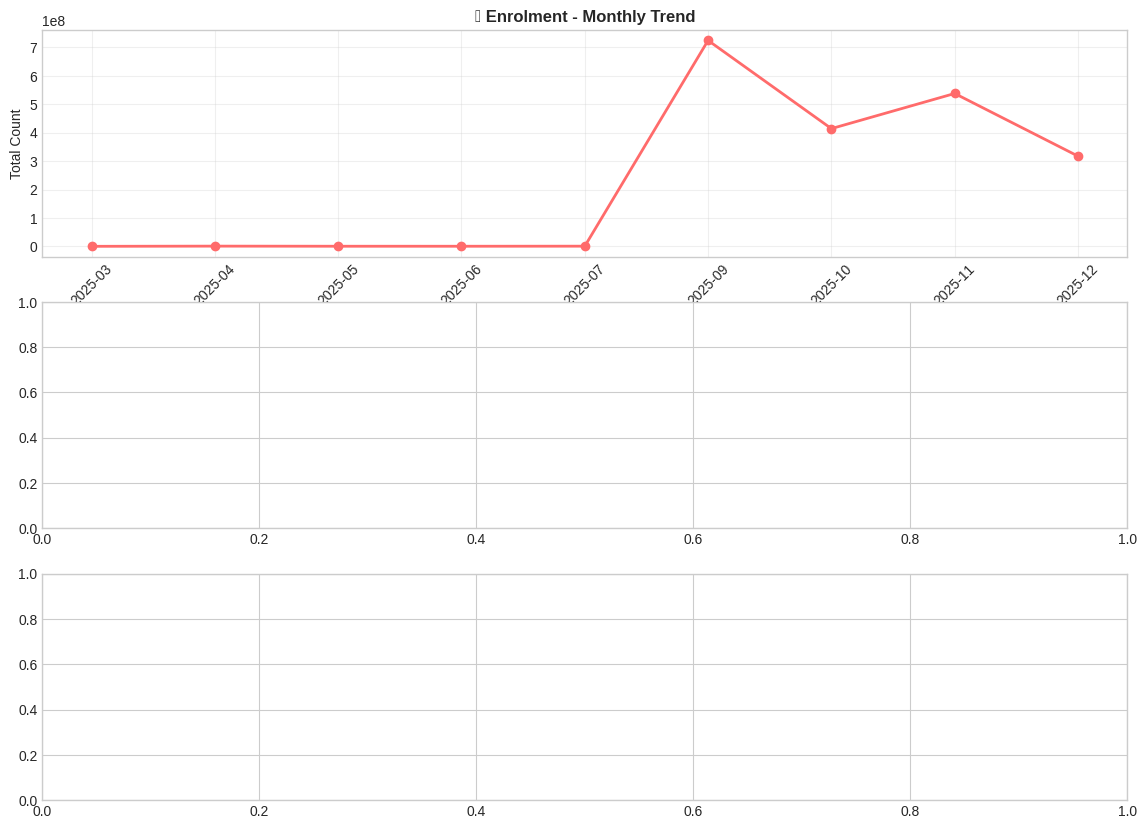

In [16]:
# Monthly trends overview
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for idx, (name, df) in enumerate(datasets.items()):
    # Identify numeric columns (age groups)
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if 'pincode' not in c.lower()]
    
    # Monthly totals - FIXED VERSION
    df['month'] = df['date'].dt.to_period('M').astype(str)
    df['total'] = df[numeric_cols].sum(axis=1)
    monthly = df.groupby('month')['total'].sum()
    
    axes[idx].plot(monthly.index, monthly.values, 
                   marker='o', linewidth=2, markersize=6, color=colors[idx])
    axes[idx].set_title(f'📈 {name} - Monthly Trend', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Total Count')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 6️⃣ Key Observations

### Summary:
- **Enrolment**: New Aadhaar registrations with age group breakdown (0-5, 5-17, 18+)
- **Demographic**: Updates to demographic info with same age breakdown
- **Biometric**: Biometric updates with age breakdown (5-17, 17+)

### Data Quality:
- All datasets have been pre-cleaned
- Date ranges span the analysis period
- Geographic coverage includes all states and union territories

### Next Steps:
- Proceed to **02_deep_dive_eda.ipynb** for detailed analysis
- Explore state-wise patterns and temporal trends

In [ ]:
print('\n' + '=' * 60)
print('✅ DATA EXPLORATION COMPLETE!')
print('=' * 60)
print('\n📌 Next: Open 02_deep_dive_eda.ipynb for detailed analysis')